In [1]:
#autoreload imports
%load_ext autoreload
%autoreload 2

#setting os path to import scripts
import os
import sys

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

# imports
from deep_lens_modeling.network_predictions import generate_sequential_predictions
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.Plots import lens_plot
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
from scipy.stats import multivariate_normal
from complexLA.Analysis import network_predictions, fermat_potentials
import statistics

lens model:  <lenstronomy.LensModel.lens_model.LensModel object at 0x000001E3CB465880>


In [3]:
#Defining sample number in case the above parameter generation was not ran
sample_num = 101

#Parameter predictions for test set without a perturber
image_path_main_deflector = '../images_for_network/main_deflector/'
y_test, y_pred_wop, std_pred_wop, prec_pred_wop = network_predictions.Predictions(image_path_main_deflector)

#Parameter predictions for test set with a dark perturber
image_path_dark_perturber = '../images_for_network/dark_perturber/'
y_test, y_pred_wp, std_pred_wp, prec_pred_wp = network_predictions.Predictions(image_path_dark_perturber)

#Parameter predictions for test set with a luminous perturber
image_path_luminous_perturber = '../images_for_network/luminous_perturber/'
y_test, y_pred_wpl, std_pred_wpl, prec_pred_wpl = network_predictions.Predictions(image_path_luminous_perturber)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [31]:
print(type(y_test[1]))
print(y_test[1])

<class 'numpy.ndarray'>
[ 0.68561757 -0.02894939  0.3354346   1.8391432   0.30538204 -0.39806953
 -0.02255297  0.06987721  0.15375224  0.0375539 ]


In [23]:
y_test, y_pred_wop, std_pred_wop, prec_pred_wop, y_pred_wp, std_pred_wp, prec_pred_wp, y_pred_wpl, std_pred_wpl, prec_pred_wpl = network_predictions.Predictions(config_path, image_path, sample_num=sample_num)

Running: python /Users/Logan/AppData/Local/Programs/Python/Python312/Lib/site-packages/paltas/paltas/generate.py ../complexLA/Configs ../complexLA/Images_for_Network --n 101 --tf_record
STDOUT: Save folder path: ../complexLA/Images_for_Network

STDERR: 2026-05-07 11:23:38.245593: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 11:23:40.096430: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Traceback (most recent call last):
  File "c:\Users\Logan\AppData\Local\Programs\Python\Python312\Lib\site-packages\paltas\paltas\generate.py", line 159, in <m

NotFoundError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} NewRandomAccessFile failed to Create/Open: ../complexLA/Images_for_Network\data.tfrecord : The system cannot find the file specified.
; No such file or directory [Op:IteratorGetNext] name: 

In [32]:
#Finding image positions
x_im_test = []
y_im_test = []

for i in range(sample_num-1):
    x_im_test_val, y_im_test_val = fermat_potentials.fermat.image_positions_from_y_pred(y_test[i])
    x_im_test.append(x_im_test_val)
    y_im_test.append(y_im_test_val)
print(x_im_test[1])
print(y_im_test[1])

[ 0.98770384 -0.50125342  0.36843334 -0.15053255]
[ 1.09778503 -0.90136802 -0.2307369   0.12739377]


In [ ]:
x_im_pred_wop = []
y_im_pred_wop = []

for i in range(sample_num-1):
    x_im_pred_val, y_im_pred_val = fermat_potentials.fermat.image_positions_from_y_pred(y_pred_wop[i])
    x_im_pred_wop.append(x_im_pred_val)
    y_im_pred_wop.append(y_im_pred_val)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
x_im_pred_wp = []
y_im_pred_wp = []

for i in range(sample_num-1):
    x_im_pred_val, y_im_pred_val = fermat_potentials.fermat.image_positions_from_y_pred(y_pred_wp[i])
    x_im_pred_wp.append(x_im_pred_val)
    y_im_pred_wp.append(y_im_pred_val)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
x_im_pred_wpl = []
y_im_pred_wpl = []

for i in range(sample_num-1):
    x_im_pred_val, y_im_pred_val = fermat_potentials.fermat.image_positions_from_y_pred(y_pred_wpl[i])
    x_im_pred_wpl.append(x_im_pred_val)
    y_im_pred_wpl.append(y_im_pred_val)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
params_dist_wop = []
for i in range(sample_num-1):
    covariance_matrix = np.diag(std_pred_wop[i]**2)
    params_dist_val = multivariate_normal.rvs(mean=y_pred_wop[i],cov=covariance_matrix,size=1000)
    #plt.hist(params_dist[:,3])
    params_dist_wop.append(params_dist_val)

<class 'numpy.ndarray'>


In [ ]:
params_dist_wp = []
for i in range(sample_num-1):
    covariance_matrix = np.diag(std_pred_wp[i]**2)
    params_dist_val = multivariate_normal.rvs(mean=y_pred_wp[i],cov=covariance_matrix,size=1000)
    #plt.hist(params_dist[:,3])
    params_dist_wp.append(params_dist_val)

<class 'numpy.ndarray'>


In [ ]:
params_dist_wpl = []
for i in range(sample_num-1):
    covariance_matrix = np.diag(std_pred_wpl[i]**2)
    params_dist_val = multivariate_normal.rvs(mean=y_pred_wpl[i],cov=covariance_matrix,size=1000)
    #plt.hist(params_dist[:,3])
    params_dist_wpl.append(params_dist_val)

<class 'numpy.ndarray'>


lens model:  <lenstronomy.LensModel.lens_model.LensModel object at 0x000001E419DAAF90>
Missing fermat potential differences: 0


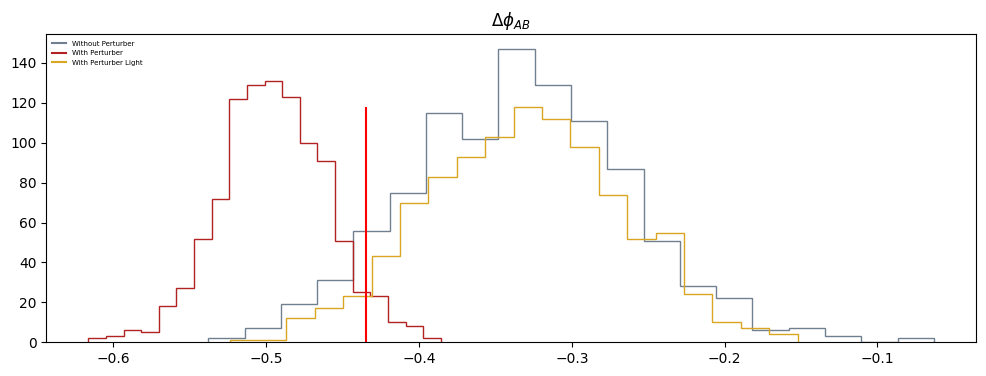

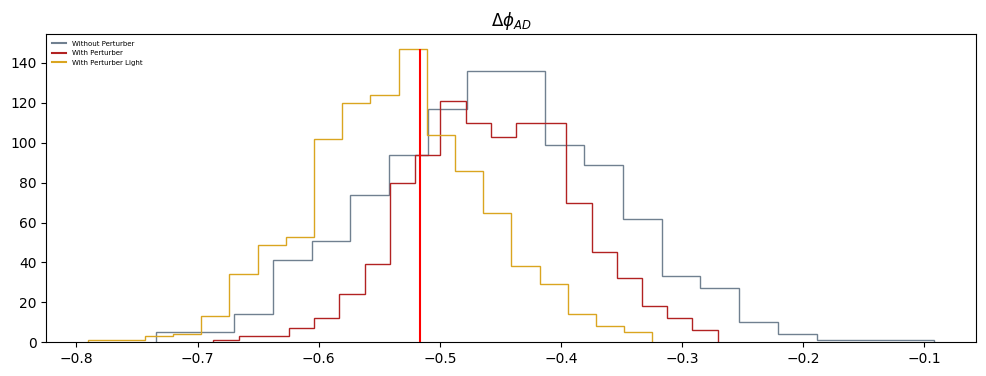

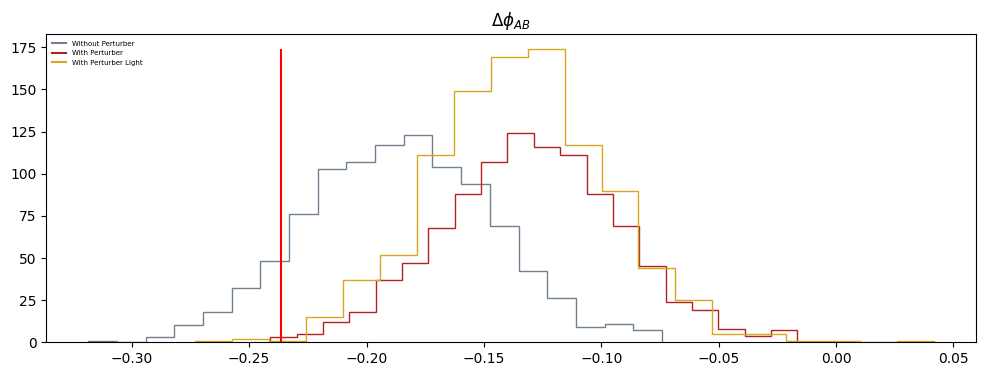

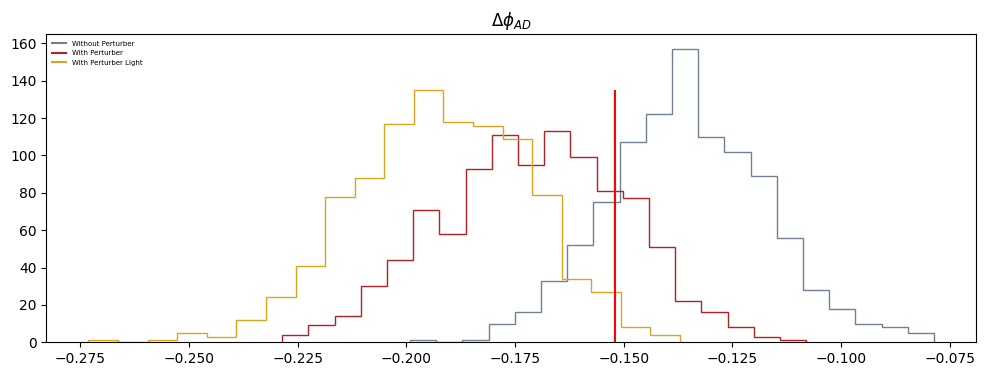

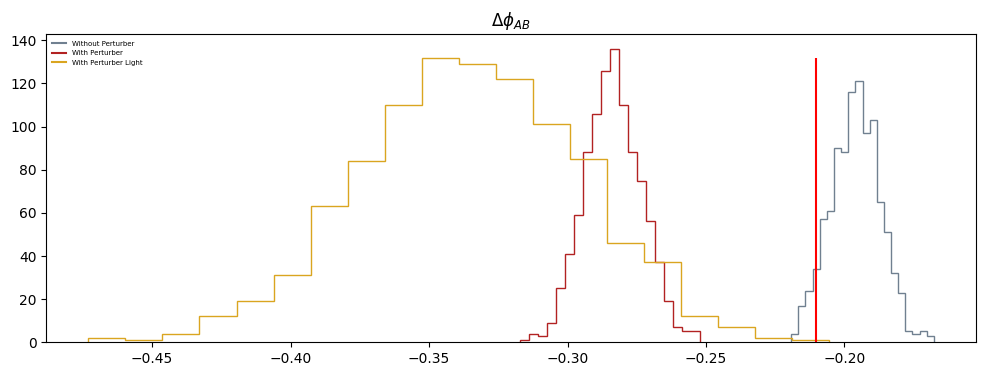

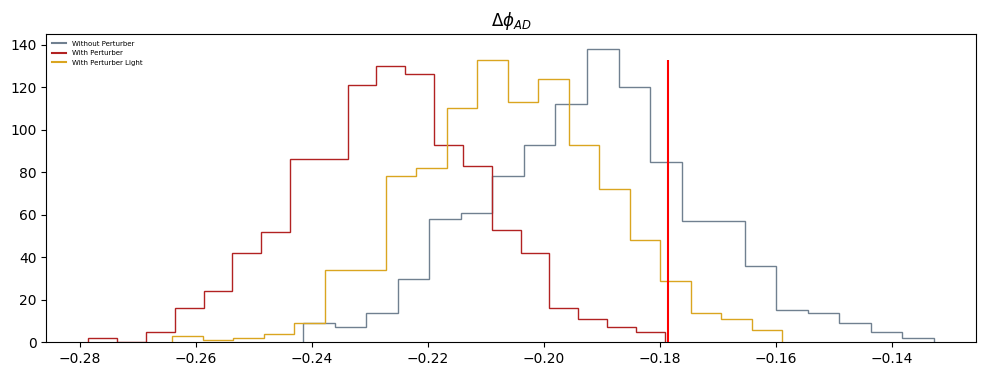

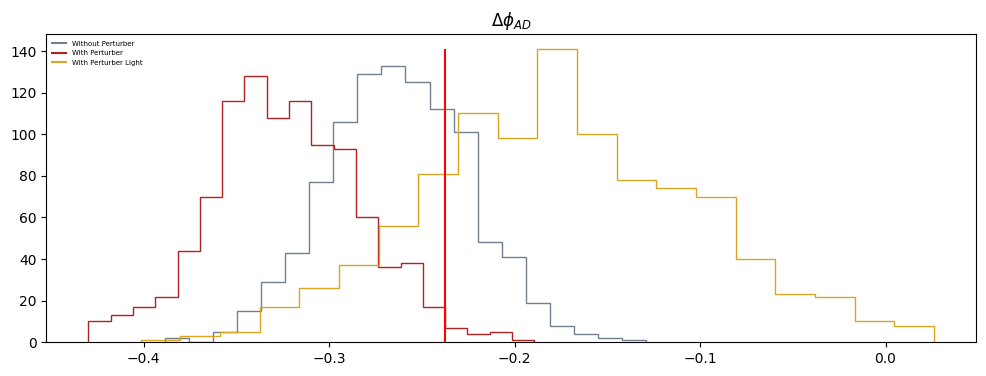

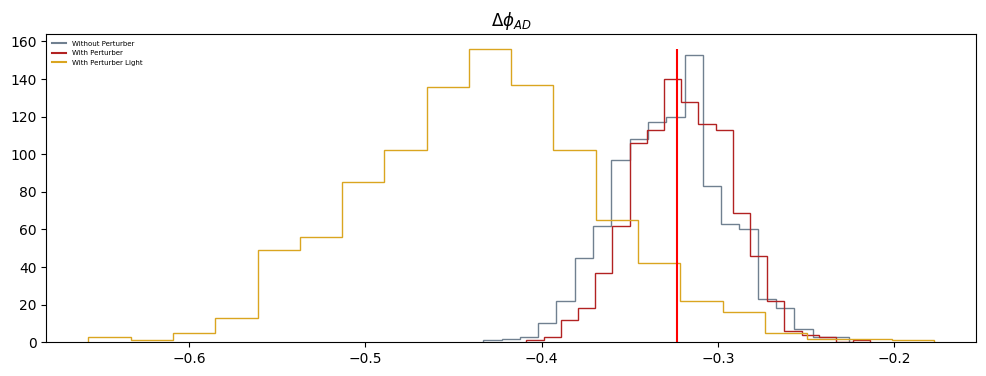

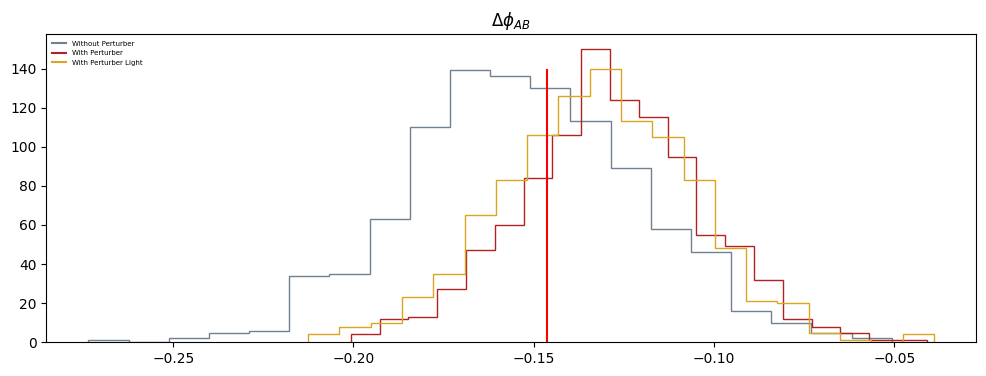

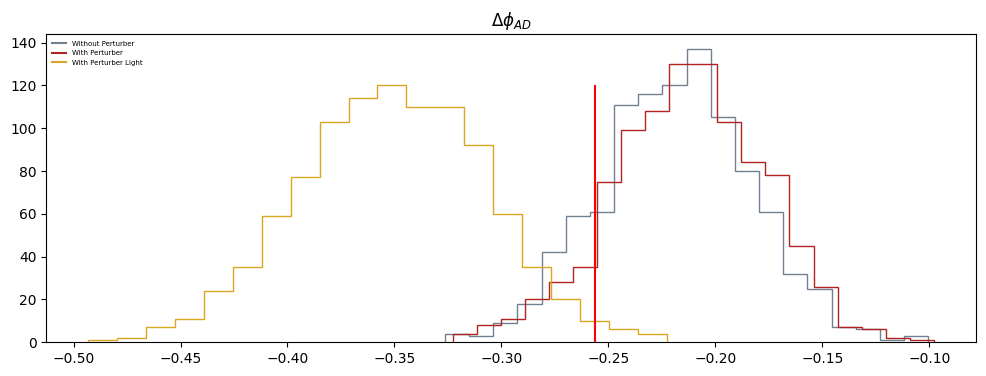

In [46]:
# Plotting histograms
n = 0
color = ['slategray', 'firebrick', 'goldenrod']
label = ['Without Perturber', 'With Perturber', 'With Perturber Light']

for i in range(sample_num-1):
    truth_fermat_potentials = (fermat_potentials.fermat.fermat_potential_at_image_positions(y_test[i], x_im_test[i], y_im_test[i]))
    
    #Find location of largest time delay and plot one set of hitograms for each quad
    if truth_fermat_potentials.shape == (4,):
        shape = 3
        sample_wop_arr,sample_wp_arr,sample_wpl_arr,truth_arr,abs_max_loc = fermat_potentials.fermat.largest_truth_value(
        shape,params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],x_im_test[i],y_im_test[i],truth_fermat_potentials)
        if i<10:
            fig,axs = plt.subplots(1,figsize=(12,4))
            im_labels = ['AB','AC','AD']
            counts,bins,_ = axs.hist(sample_wop_arr[abs_max_loc],bins=20, histtype=u'step', color='slategray')
            counts,bins,_ = axs.hist(sample_wp_arr[abs_max_loc],bins=20, histtype=u'step', color='firebrick')
            counts,bins,_ = axs.hist(sample_wpl_arr[abs_max_loc],bins=20, histtype=u'step', color='goldenrod')
            axs.vlines(truth_arr[abs_max_loc],0,np.max(counts),zorder=200,color='red')
            axs.set_title('$\Delta\phi_{'+im_labels[abs_max_loc]+'}$')
            axs.legend(handles=[mlines.Line2D([], [], color=color[i], label=label[i]) for i in range(0,3)],frameon=False, fontsize=5,loc='upper left')

    elif truth_fermat_potentials.shape == (3,):
        shape = 2
        sample_wop_arr,sample_wp_arr,sample_wpl_arr,truth_arr,abs_max_loc = fermat_potentials.fermat.largest_truth_value(
            shape,params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],x_im_test[i],y_im_test[i],truth_fermat_potentials)
        if i<10:
            fig,axs = plt.subplots(1,figsize=(12,4))
            im_labels = ['AB','AC']
            counts,bins,_ = axs.hist(sample_wop_arr[abs_max_loc],bins=20, histtype=u'step', color='slategray')
            counts,bins,_ = axs.hist(sample_wp_arr[abs_max_loc],bins=20, histtype=u'step', color='firebrick')
            counts,bins,_ = axs.hist(sample_wpl_arr[abs_max_loc],bins=20, histtype=u'step', color='goldenrod')
            axs.vlines(truth_arr[abs_max_loc],0,np.max(counts),zorder=200,color='red')
            axs.set_title('$\Delta\phi_{'+im_labels[abs_max_loc]+'}$')
            axs.legend(handles=[mlines.Line2D([], [], color=color[i], label=label[i]) for i in range(0,3)],frameon=False, fontsize=5,loc='upper left')

    elif truth_fermat_potentials.shape == (2,):
        sampled_fermat_potentials_wop,sampled_fermat_potentials_wp,sampled_fermat_potentials_wpl = fermat_potentials.fermat.fermat_potential_arrays(
            params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],x_im_test[i],y_im_test[i])
        if i<10:
            fig,axs = plt.subplots(1,figsize=(12,4))
            counts,bins,_ = axs.hist(sampled_fermat_potentials_wop[:,0]-sampled_fermat_potentials_wop[:,1],bins=20, histtype=u'step',
                                            color='slategray')
            counts,bins,_ = axs.hist(sampled_fermat_potentials_wp[:,0]-sampled_fermat_potentials_wp[:,1],bins=20, histtype=u'step',
                                            color='firebrick')
            counts,bins,_ = axs.hist(sampled_fermat_potentials_wpl[:,0]-sampled_fermat_potentials_wpl[:,1],bins=20, histtype=u'step',
                                            color='goldenrod')
            axs.vlines(truth_fermat_potentials[0]-truth_fermat_potentials[1],0,np.max(counts),zorder=200,color='red')
            axs.set_title('$\Delta\phi_{AB}$')
            axs.legend(handles=[mlines.Line2D([], [], color=color[i], label=label[i]) for i in range(0,3)],frameon=False,
                    fontsize=5,loc='upper left')

    else:
        print('Index:'+str(i))
        print('Sampled fermat potentials WoP size: '+str(sampled_fermat_potentials_wop[i].shape))
        print('Sampled fermat potentials WP size: '+str(sampled_fermat_potentials_wp[i].shape))
        print('Sampled fermat potentials WPL size: '+str(sampled_fermat_potentials_wpl[i].shape))
        print('Truth fermat potentials size: '+str(truth_fermat_potentials.shape))
        n = n+1

print('Missing fermat potential differences: '+str(n))

0.018091081989205504


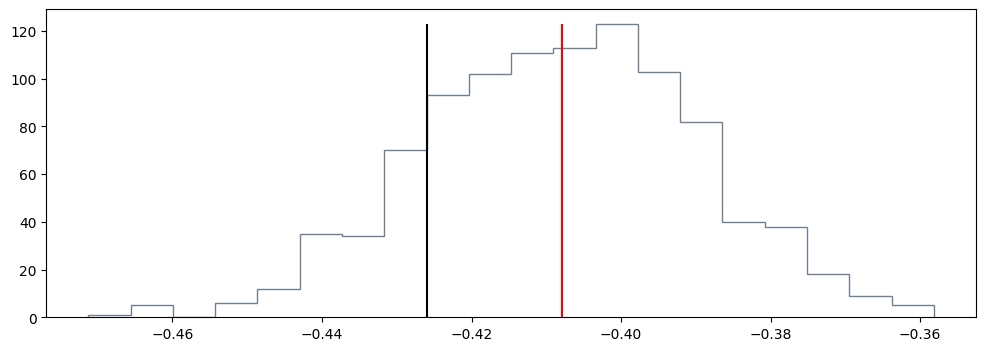

In [42]:
test = sample_wop_arr[abs_max_loc]
#print(test)
median = statistics.median(test)
fig,axs = plt.subplots(1,figsize=(12,4))
counts,bins,_ = axs.hist(sample_wop_arr[abs_max_loc],bins=20, histtype=u'step', color='slategray')
axs.vlines(median,0,np.max(counts),zorder=200,color='red')
axs.vlines(truth_arr[abs_max_loc],0,np.max(counts),zorder=200,color='black')
print(median-truth_arr[abs_max_loc])

### Calculate Metrics

In [43]:
#Accurace and Bias
acc_arr_wop = []
acc_arr_wp = []
acc_arr_wpl = []

bias_arr_wop = []
bias_arr_wp = []
bias_arr_wpl = []

for i in range(sample_num-1):
    truth_fermat_potentials = (fermat_potentials.fermat.fermat_potential_at_image_positions(y_test[i], x_im_test[i], y_im_test[i]))

    if truth_fermat_potentials.shape == (4,):
        shape = 3
        sample_wop_arr,sample_wp_arr,sample_wpl_arr,truth_arr,abs_max_loc = fermat_potentials.fermat.largest_truth_value(
            shape,params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],y_test[i],x_im_test[i],y_im_test[i],truth_fermat_potentials)
        median_wop = statistics.median(sample_wop_arr[abs_max_loc])
        median_wp = statistics.median(sample_wp_arr[abs_max_loc])
        median_wpl = statistics.median(sample_wpl_arr[abs_max_loc])
        truth = truth_arr[abs_max_loc]
        bias_arr_wop.append(median_wop-truth)
        bias_arr_wp.append(median_wp-truth)
        bias_arr_wpl.append(median_wpl-truth)
        acc_arr_wop.append(np.abs(median_wop-truth))
        acc_arr_wp.append(np.abs(median_wp-truth))
        acc_arr_wpl.append(np.abs(median_wpl-truth))

    elif truth_fermat_potentials.shape == (3,):
        shape = 2
        sample_wop_arr,sample_wp_arr,sample_wpl_arr,truth_arr,abs_max_loc = fermat_potentials.fermat.largest_truth_value(
            shape,params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],y_test[i],x_im_test[i],y_im_test[i],truth_fermat_potentials)
        median_wop = statistics.median(sample_wop_arr[abs_max_loc])
        median_wp = statistics.median(sample_wp_arr[abs_max_loc])
        median_wpl = statistics.median(sample_wpl_arr[abs_max_loc])
        truth = truth_arr[abs_max_loc]
        bias_arr_wop.append(median_wop-truth)
        bias_arr_wp.append(median_wp-truth)
        bias_arr_wpl.append(median_wpl-truth)
        acc_arr_wop.append(np.abs(median_wop-truth))
        acc_arr_wp.append(np.abs(median_wp-truth))
        acc_arr_wpl.append(np.abs(median_wpl-truth))

    elif truth_fermat_potentials.shape == (2,):
        sampled_fermat_potentials_wop,sampled_fermat_potentials_wp,sampled_fermat_potentials_wpl = fermat_potentials.fermat.fermat_potential_arrays(
            params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],y_test[i],x_im_test[i],y_im_test[i])
        sample_wop = sampled_fermat_potentials_wop[:,0]-sampled_fermat_potentials_wop[:,1]
        sample_wp = sampled_fermat_potentials_wp[:,0]-sampled_fermat_potentials_wp[:,1]
        sample_wpl = sampled_fermat_potentials_wpl[:,0]-sampled_fermat_potentials_wpl[:,1]
        median_wop = statistics.median(sample_wop)
        median_wp = statistics.median(sample_wp)
        median_wpl = statistics.median(sample_wpl)
        truth = truth_fermat_potentials[0]-truth_fermat_potentials[1]
        bias_arr_wop.append(median_wop-truth)
        bias_arr_wp.append(median_wp-truth)
        bias_arr_wpl.append(median_wpl-truth)
        acc_arr_wop.append(np.abs(median_wop-truth))
        acc_arr_wp.append(np.abs(median_wp-truth))
        acc_arr_wpl.append(np.abs(median_wpl-truth))

bias_metric_wop = statistics.mean(bias_arr_wop)
bias_metric_wp = statistics.mean(bias_arr_wp)
bias_metric_wpl = statistics.mean(bias_arr_wpl)
acc_metric_wop = statistics.mean(acc_arr_wop)
acc_metric_wp = statistics.mean(acc_arr_wp)
acc_metric_wpl = statistics.mean(acc_arr_wpl)
print('Accuracy of WoP: '+str(acc_metric_wop))
print('Accuracy of WP: '+str(acc_metric_wp))
print('Accuracy of WPL: '+str(acc_metric_wpl))
print('Bias of WoP: '+str(bias_metric_wop))
print('Bias of WP: '+str(bias_metric_wp))
print('Bias of WPL: '+str(bias_metric_wpl))

Accuracy of WoP: 0.020583804657191104
Accuracy of WP: 0.03934181025614806
Accuracy of WPL: 0.06832893526934988
Bias of WoP: 0.008215805941975532
Bias of WP: -0.00877733386746019
Bias of WPL: 0.030999018973800998


In [44]:
#Precision

prec_arr_wop = []
prec_arr_wp = []
prec_arr_wpl = []

for i in range(sample_num-1):
    truth_fermat_potentials = (fermat_potentials.fermat.fermat_potential_at_image_positions(y_test[i], x_im_test[i], y_im_test[i]))

    if truth_fermat_potentials.shape == (4,):
        shape = 3
        sample_wop_arr,sample_wp_arr,sample_wpl_arr,truth_arr,abs_max_loc = fermat_potentials.fermat.largest_truth_value(
            shape,params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],y_test[i],x_im_test[i],y_im_test[i],truth_fermat_potentials)
        std_wop = np.std(sample_wop_arr[abs_max_loc], ddof=1)
        std_wp = np.std(sample_wp_arr[abs_max_loc], ddof=1)
        std_wpl = np.std(sample_wpl_arr[abs_max_loc], ddof=1)

        prec_arr_wop.append(std_wop)
        prec_arr_wp.append(std_wp)
        prec_arr_wpl.append(std_wpl)

    elif truth_fermat_potentials.shape == (3,):
        shape = 2
        sample_wop_arr,sample_wp_arr,sample_wpl_arr,truth_arr,abs_max_loc = fermat_potentials.fermat.largest_truth_value(
            shape,params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],y_test[i],x_im_test[i],y_im_test[i],truth_fermat_potentials)
        std_wop = np.std(sample_wop_arr[abs_max_loc], ddof=1)
        std_wp = np.std(sample_wp_arr[abs_max_loc], ddof=1)
        std_wpl = np.std(sample_wpl_arr[abs_max_loc], ddof=1)

        prec_arr_wop.append(std_wop)
        prec_arr_wp.append(std_wp)
        prec_arr_wpl.append(std_wpl)

    elif truth_fermat_potentials.shape == (2,):
        sampled_fermat_potentials_wop,sampled_fermat_potentials_wp,sampled_fermat_potentials_wpl = fermat_potentials.fermat.fermat_potential_arrays(
            params_dist_wop[i],params_dist_wp[i],params_dist_wpl[i],y_test[i],x_im_test[i],y_im_test[i])
        sample_wop = sampled_fermat_potentials_wop[:,0]-sampled_fermat_potentials_wop[:,1]
        sample_wp = sampled_fermat_potentials_wp[:,0]-sampled_fermat_potentials_wp[:,1]
        sample_wpl = sampled_fermat_potentials_wpl[:,0]-sampled_fermat_potentials_wpl[:,1]
        std_wop = np.std(sample_wop, ddof=1)
        std_wp = np.std(sample_wp, ddof=1)
        std_wpl = np.std(sample_wpl, ddof=1)

        prec_arr_wop.append(std_wop)
        prec_arr_wp.append(std_wp)
        prec_arr_wpl.append(std_wpl)

prec_metric_wop = statistics.mean(prec_arr_wop)
prec_metric_wp = statistics.mean(prec_arr_wp)
prec_metric_wpl = statistics.mean(prec_arr_wpl)
print('Precision of WoP: '+str(prec_metric_wop))
print('Precision of WP: '+str(prec_metric_wp))
print('Precision of WPL: '+str(prec_metric_wpl))

Precision of WoP: 0.03274593581604613
Precision of WP: 0.032992304152879987
Precision of WPL: 0.054727949375234314


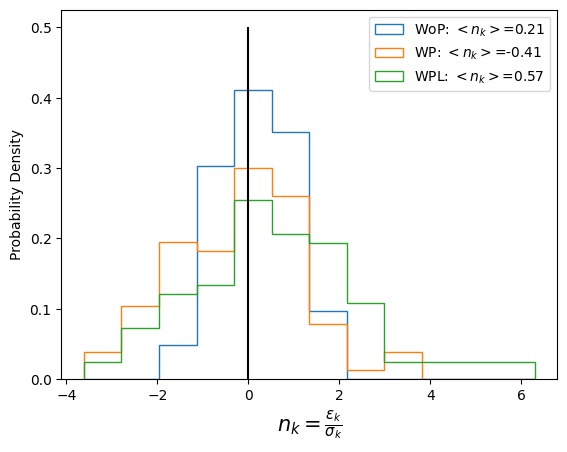

In [45]:
bias_arr_wop = np.array(bias_arr_wop)
bias_arr_wp = np.array(bias_arr_wp)
bias_arr_wpl = np.array(bias_arr_wpl)
prec_arr_wop = np.array(prec_arr_wop)
prec_arr_wp = np.array(prec_arr_wp)
prec_arr_wpl = np.array(prec_arr_wpl)

n_wop = bias_arr_wop/prec_arr_wop
n_wp = bias_arr_wp/prec_arr_wp
n_wpl = bias_arr_wpl/prec_arr_wpl

n_wop_mean = np.mean(n_wop)
n_wp_mean = np.mean(n_wp)
n_wpl_mean = np.mean(n_wpl)

_,bin_edges = np.histogram(n_wpl,12)

plt.hist(n_wop,bins=bin_edges, histtype=u'step', density=True, label="WoP: $<n_k>$=%.2f"%(n_wop_mean))
plt.hist(n_wp,bins=bin_edges, histtype=u'step', density=True, label="WP: $<n_k>$=%.2f"%(n_wp_mean))
plt.hist(n_wpl,bins=bin_edges, histtype=u'step', density=True, label="WPL: $<n_k>$=%.2f"%(n_wpl_mean))
plt.vlines(0,0,0.5,color='black')
plt.xlabel(r'$n_k=\frac{\epsilon_k}{\sigma_k}$',fontsize=15)
plt.ylabel('Probability Density')
plt.legend()
plt.savefig('/Users/Logan/Documents/SJSU/HEP_Research/ComplexLA/docs/figures/Sigma_standard_error.png',bbox_inches='tight')